<a href="https://colab.research.google.com/github/hbistlin/ie332-fall2026/blob/main/Copy_of_Lab6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 6: Predicting Shots with Logistic Regression and Trees

**IE 332, Week 7.** Submit the completed notebook to Gradescope by Sunday
at 11:59 p.m. This lab is graded for completion. AI is allowed in lab;
you are responsible for understanding your code and explanations.

Can a more flexible model predict new shots better? Use the synthetic
Boiler City Bears shot log, `nba_shots.csv`. One row is one shot attempt.
Use only these two model inputs, in this order: `dist_ft`, `defender_ft`.
The target is `made`. Other columns are not model inputs in this lab.

| Column used here | Meaning |
| --- | --- |
| `dist_ft` | Distance from the shooter to the basket, in feet. |
| `defender_ft` | Distance from the shooter to the nearest defender, in feet. |
| `made` | Recorded outcome: 1 = make, 0 = miss. |

Open this notebook in Colab and upload `nba_shots.csv` to its **Files**
panel. No other file is needed. Run the supplied setup unchanged, then
complete the empty code and response cells in order. Aim for about
**50 minutes**: setup 5, Q1 10, Q2 12, Q3 15, Q4 8. Use the remaining
session time for questions, debugging, and checking your work.

## Setup (supplied)

Keep the same split throughout: **60% training** to fit models and explore
patterns, **20% validation** to choose a model, and **20% test** for one final
evaluation in Q4. The second split takes 25% of the remaining 80%, giving
20% of all rows. The seed repeats the allocation; each input row stays
paired with its outcome.

In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

if not Path("nba_shots.csv").is_file():
    raise FileNotFoundError("Upload nba_shots.csv to Colab's Files panel, then rerun this cell.")
shots = pd.read_csv("nba_shots.csv")
FEATURES = ["dist_ft", "defender_ft"]

train_valid, test = train_test_split(shots, test_size=0.20, random_state=332)
train, valid = train_test_split(train_valid, test_size=0.25, random_state=332)
X_train, y_train = train[FEATURES], train["made"]
X_valid, y_valid = valid[FEATURES], valid["made"]
X_test, y_test = test[FEATURES], test["made"]

print("Rows (training, validation, test):", len(train), len(valid), len(test))
display(train[FEATURES + ["made"]].head(3))

Rows (training, validation, test): 12000 4000 4000


,dist_ft,defender_ft,made
11152,9.8,6.8,0
19051,29.8,7.0,1
7974,21.8,6.3,1


## Q1. Compare distances for makes and misses

Using **only `train`**, create `distance_summary` with one row for each
recorded outcome (`made` = 0 or 1) and columns `attempts` (number of shots)
and `median_dist_ft` (median shot distance). Display the table. Make a
box plot comparing shot distance for misses and makes, with labeled axes
and units.

In two sentences, compare the medians and the overlap between the two
distributions. Do your results suggest that shot distance alone could
perfectly separate makes from misses? Explain.

,made,attempts,median_dist_ft
0,0,6073,18.2
1,1,5927,8.4


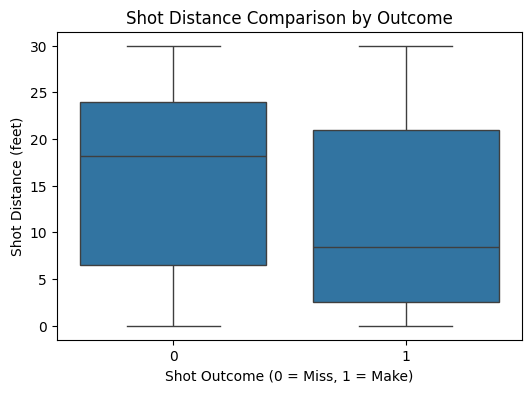

In [ ]:
distance_summary = (
    train.groupby("made")["dist_ft"]
    .agg(attempts="count", median_dist_ft="median")
    .reset_index()
)

display(distance_summary)

plt.figure(figsize=(6, 4))
sns.boxplot(data=train, x="made", y="dist_ft")
plt.xlabel("Shot Outcome (0 = Miss, 1 = Make)")
plt.ylabel("Shot Distance (feet)")
plt.title("Shot Distance Comparison by Outcome")
plt.show()

The median distace of the missed shots was around 18ft, whereas the median distance for the made shots was around 8 feet. There is a rather significant overlap between missed and made shots, so while shot distance is clearly a factor in determining misses vs. makes, it cannot be used as the sole predictor.

## Q2. Compare predictions for new shots

Fit `logistic = LogisticRegression(max_iter=2000)` and
`tree2 = DecisionTreeClassifier(max_depth=2, random_state=332)` using
`X_train, y_train`. Keep other settings at their defaults.

The supplied `new_shots` contains four hypothetical attempts, not rows
used for validation or testing. Create and display `predictions`: the two
feature columns plus `logistic_p`, `logistic_class`, `tree_p`, and
`tree_class`, using `predict_proba` and `predict`. Round only the displayed
probabilities to three decimals.

Print each model's `classes_`: probability columns follow that order.
With classes `[0, 1]`, `predict_proba(new_shots)[:, 1]` selects the make
probability for every row (the second column).

In two sentences: compare A with B within each model, then identify a shot
for which the models predict different classes. Explain why the predicted
class is not a guarantee of the actual outcome.

In [ ]:
new_shots = pd.DataFrame({
    "dist_ft": [8.0, 8.0, 24.0, 24.0],
    "defender_ft": [2.0, 8.0, 2.0, 8.0],
}, index=["A", "B", "C", "D"])
display(new_shots)

,dist_ft,defender_ft
A,8.0,2.0
B,8.0,8.0
C,24.0,2.0
D,24.0,8.0


In [ ]:
logistic = LogisticRegression(max_iter=2000)
tree2 = DecisionTreeClassifier(max_depth=2, random_state=332)

logistic.fit(X_train, y_train)
tree2.fit(X_train, y_train)

print("Logistic classes:", logistic.classes_)
print("Tree classes:", tree2.classes_)

predictions = new_shots.copy()
predictions["logistic_p"] = logistic.predict_proba(new_shots)[:, 1]
predictions["logistic_class"] = logistic.predict(new_shots)
predictions["tree_p"] = tree2.predict_proba(new_shots)[:, 1]
predictions["tree_class"] = tree2.predict(new_shots)
display(predictions.round(3))

Logistic classes: [0 1]
Tree classes: [0 1]


,dist_ft,defender_ft,logistic_p,logistic_class,tree_p,tree_class
A,8.0,2.0,0.481,0,0.527,1
B,8.0,8.0,0.700,1,0.527,1
C,24.0,2.0,0.281,0,0.277,0
D,24.0,8.0,0.497,0,0.466,0


B in both models is consistent, albeit with a different prediction value, both models agree that the shot will be a make. A, however, differs between the two models, with the logistic model classing it as a miss and the tree model classing it as a make, and differences like these prove why models cannot be used as a guarantee of outcome.

## Q3. Choose a model using validation data

Fit one more candidate on the **same training rows and features**:
`deep_tree = DecisionTreeClassifier(random_state=332)`. Without a
`max_depth` limit, it can keep splitting as the training data allow.

**Accuracy** is the fraction of predictions that match the recorded
labels. For example, `(model.predict(X_valid) == y_valid).mean()` computes
validation accuracy: the comparison produces True/False values, whose
mean is the fraction correct.

Create `scores` with rows `logistic`, `tree2`, `deep_tree` and columns
`training_accuracy`, `validation_accuracy`. Display it rounded to three
decimals, keeping unrounded values stored. Do not use test rows here.

Choose one candidate and assign that **already-fitted model** to
`chosen_model`. In two or three sentences, justify your choice with the
validation results and explain what the training-versus-validation
comparison tells you about the unrestricted tree. Small score differences
on one split do not establish a reliable ranking on future data.

In [ ]:
logistic = LogisticRegression(max_iter=2000)
tree2 = DecisionTreeClassifier(max_depth=2, random_state=332)
deep_tree = DecisionTreeClassifier(random_state=332)

logistic.fit(X_train, y_train)
tree2.fit(X_train, y_train)
deep_tree.fit(X_train, y_train)

scores = pd.DataFrame(
    {
        "training_accuracy": [
            (logistic.predict(X_train) == y_train).mean(),
            (tree2.predict(X_train) == y_train).mean(),
            (deep_tree.predict(X_train) == y_train).mean(),
        ],
        "validation_accuracy": [
            (logistic.predict(X_valid) == y_valid).mean(),
            (tree2.predict(X_valid) == y_valid).mean(),
            (deep_tree.predict(X_valid) == y_valid).mean(),
        ],
    },
    index=["logistic", "tree2", "deep_tree"],
)
display(scores.round(3))
chosen_model = logistic

,training_accuracy,validation_accuracy
logistic,0.617,0.626
tree2,0.620,0.624
deep_tree,0.888,0.553


We have chosen the logistic model due to it holding the highest validation_accuracy score. The unrestricted tree manages a very high training_accuracy score, but ends up with the lowest validation_accuracy score.

## Q4. Evaluate your selected model

After recording your Q3 choice and explanation, use `chosen_model` to
predict `X_test`. Store the predictions in `test_predictions` and their
accuracy in `test_accuracy`. Display the accuracy to three decimals.
Evaluate **only this model**, without retraining or changing your choice
after seeing the test result.

In two sentences, interpret your test accuracy as an approximate number
of correct predictions per 100 similar new shots. Explain why the test
rows were kept out of model selection.

In [ ]:
test_predictions = chosen_model.predict(X_test)
test_accuracy = (test_predictions == y_test).mean()
print(f"Test Accuracy: {test_accuracy:.3f}")

Test Accuracy: 0.629


A test accuracy of .629 imples that of 100 shots taken, roughly 63 would be predicted correctly. The test rows were kept out of model selection because they are hypothetical attempts, not true data.

## Before submitting

Restart the runtime and run the completed notebook from top to bottom.
Check that the chart, summary tables, predictions, final test accuracy,
and four short responses are saved and there are no errors. Submit the
`.ipynb` file to **Gradescope: Lab 6**.